In [1]:
import sys
import warnings
import itertools
import calendar
from pylab import rcParams
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv('TimeSeries.xls')

In [3]:
df.head()

,Date,Value
0,01-07-1991,3.526591
1,01-08-1991,3.180891
2,01-09-1991,3.252221
3,01-10-1991,3.611003
4,01-11-1991,3.565869


In [4]:
data = df.copy()

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    204 non-null    object 
 1   Value   204 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB


In [6]:
dates = pd.date_range(start='1/1/1991', periods=len(data), freq='M')

In [7]:
dates

DatetimeIndex(['1991-01-31', '1991-02-28', '1991-03-31', '1991-04-30',
               '1991-05-31', '1991-06-30', '1991-07-31', '1991-08-31',
               '1991-09-30', '1991-10-31',
               ...
               '2007-03-31', '2007-04-30', '2007-05-31', '2007-06-30',
               '2007-07-31', '2007-08-31', '2007-09-30', '2007-10-31',
               '2007-11-30', '2007-12-31'],
              dtype='datetime64[ns]', length=204, freq='M')

In [8]:
data['Month'] = dates.month
data['Month'] = data['Month'].apply(lambda x: calendar.month_abbr[x])
data['Year'] = dates.year

In [9]:
data.drop('Date', axis=1, inplace=True)

In [10]:
data.set_index(dates, inplace=True)

In [11]:
data.head()

,Value,Month,Year
1991-01-31,3.526591,Jan,1991
1991-02-28,3.180891,Feb,1991
1991-03-31,3.252221,Mar,1991
1991-04-30,3.611003,Apr,1991
1991-05-31,3.565869,May,1991


In [12]:
sales_ts = data['Value']

In [13]:
sales_ts

1991-01-31     3.526591
1991-02-28     3.180891
1991-03-31     3.252221
1991-04-30     3.611003
1991-05-31     3.565869
                ...    
2007-08-31    21.654285
2007-09-30    18.264945
2007-10-31    23.107677
2007-11-30    22.912510
2007-12-31    19.431740
Freq: M, Name: Value, Length: 204, dtype: float64

In [14]:
dftest = adfuller(sales_ts)
dftest[0]

3.145185689306745

In [15]:
dftest[1]

1.0

### Bivariate analysis

In [16]:
monthly_sales = data.pivot_table(values='Value',columns='Year',index='Month')
monthly_sales = monthly_sales.reindex(index=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
monthly_sales

Year,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
Month,,,,,,,,,,,,,,,,,
Jan,3.526591,3.737851,4.315566,4.752607,5.256742,6.486849,7.050831,7.813496,8.717420,10.834295,11.443601,12.844566,12.998046,15.339097,15.829550,16.980282,21.834890
Feb,3.180891,3.558776,4.562185,5.350605,5.855277,6.300569,6.704919,7.431892,9.070964,10.643751,11.659239,12.196500,12.517276,15.370764,17.554701,18.612189,23.930204
Mar,3.252221,3.777202,4.608662,5.204455,5.490729,6.467476,7.250988,8.275117,9.177113,9.908162,10.647060,12.854748,13.268658,16.142005,18.100864,16.623343,22.930357
Apr,3.611003,3.924490,4.667851,5.301651,6.115293,6.828629,7.819733,8.260441,9.251887,11.710041,12.652134,13.542004,14.733622,16.685754,17.496668,21.430241,23.263340
May,3.565869,4.386531,5.093841,5.773742,6.088473,6.649078,7.398101,8.596156,9.933136,11.340151,13.674466,13.287640,13.669382,17.636728,19.347265,23.575517,25.250030
Jun,4.306371,5.810549,7.179962,6.204593,7.416598,8.606937,10.096233,10.558939,11.532974,12.079132,12.965735,15.134918,16.503966,18.869325,20.031291,23.334206,25.806090
Jul,5.088335,6.192068,6.731473,6.749484,8.329452,8.524471,8.798513,10.391416,12.511462,14.497581,16.300269,16.828350,18.003768,20.778723,23.486694,28.038383,29.665356
Aug,2.814520,3.450857,3.841278,4.216067,5.069796,5.277918,5.918261,6.421535,7.457199,8.049275,9.053485,9.800215,11.938030,12.154552,12.536987,16.763869,21.654285
Sep,2.985811,3.772307,4.394076,4.949349,5.262557,5.714303,6.534493,8.062619,8.591191,10.312891,10.002449,10.816994,12.997900,13.402392,15.467018,19.792754,18.264945


In [17]:
yearly_sales = data.pivot_table(values='Value',columns='Month',index='Year')
yearly_sales = yearly_sales[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]
yearly_sales

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
1991,3.526591,3.180891,3.252221,3.611003,3.565869,4.306371,5.088335,2.814520,2.985811,3.204780,3.127578,3.270523
1992,3.737851,3.558776,3.777202,3.924490,4.386531,5.810549,6.192068,3.450857,3.772307,3.734303,3.905399,4.049687
1993,4.315566,4.562185,4.608662,4.667851,5.093841,7.179962,6.731473,3.841278,4.394076,4.075341,4.540645,4.645615
1994,4.752607,5.350605,5.204455,5.301651,5.773742,6.204593,6.749484,4.216067,4.949349,4.823045,5.194754,5.170787
1995,5.256742,5.855277,5.490729,6.115293,6.088473,7.416598,8.329452,5.069796,5.262557,5.597126,6.110296,5.689161
1996,6.486849,6.300569,6.467476,6.828629,6.649078,8.606937,8.524471,5.277918,5.714303,6.214529,6.411929,6.667716
1997,7.050831,6.704919,7.250988,7.819733,7.398101,10.096233,8.798513,5.918261,6.534493,6.675736,7.064201,7.383381
1998,7.813496,7.431892,8.275117,8.260441,8.596156,10.558939,10.391416,6.421535,8.062619,7.297739,7.936916,8.165323
1999,8.717420,9.070964,9.177113,9.251887,9.933136,11.532974,12.511462,7.457199,8.591191,8.474000,9.386803,9.560399


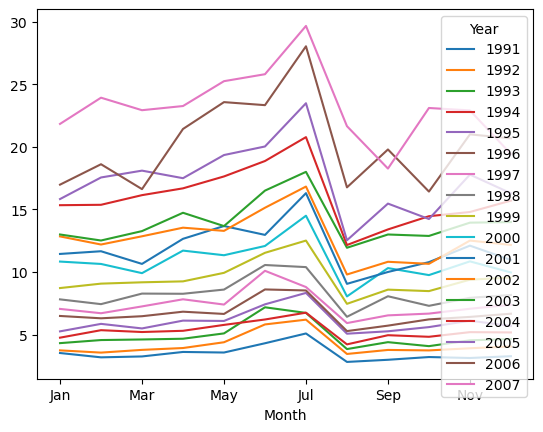

In [18]:
monthly_sales.plot()
plt.show();

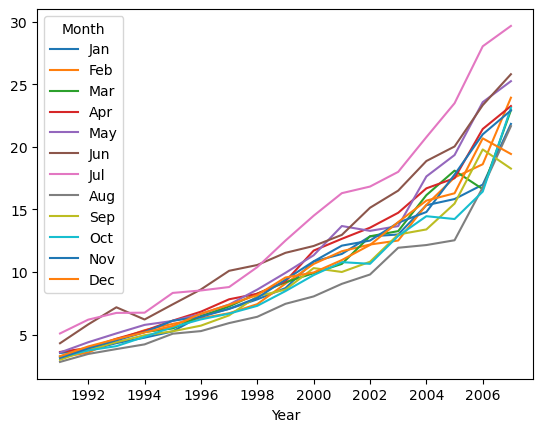

In [19]:
yearly_sales.plot()
plt.show();

### Decomposition

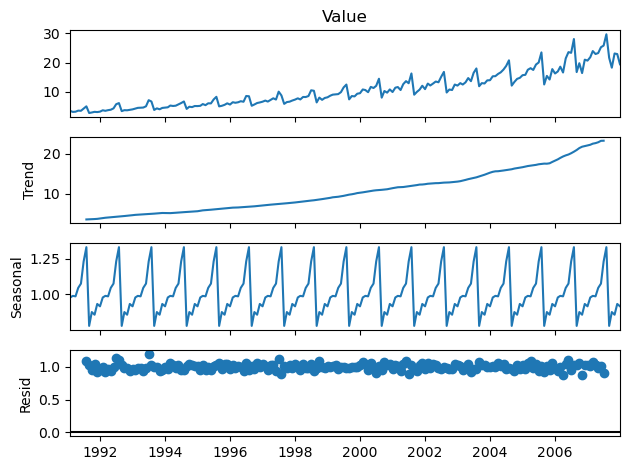

In [20]:
decomposition = sm.tsa.seasonal_decompose(sales_ts, model = 'multiplicative')
decomposition.plot()
plt.show()

### Defining the pdq estimation matrices

In [21]:
p = range(1,4)
d = range(0,2)
q = range(1,4)
pdq_ar = list(itertools.product(p, range(1), range(1)))
pdq_arma = list(itertools.product(p, range(1), q))
pdq_arima = list(itertools.product(p,d,q))
pdq_sarima = [(x[0],x[1],x[2],6) for x in list(itertools.product(p,d,q))]

In [22]:
pdq_ar

[(1, 0, 0), (2, 0, 0), (3, 0, 0)]

In [23]:
pdq_arma

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3)]

In [24]:
pdq_arima

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3)]

In [25]:
pdq_sarima

[(1, 0, 1, 6),
 (1, 0, 2, 6),
 (1, 0, 3, 6),
 (1, 1, 1, 6),
 (1, 1, 2, 6),
 (1, 1, 3, 6),
 (2, 0, 1, 6),
 (2, 0, 2, 6),
 (2, 0, 3, 6),
 (2, 1, 1, 6),
 (2, 1, 2, 6),
 (2, 1, 3, 6),
 (3, 0, 1, 6),
 (3, 0, 2, 6),
 (3, 0, 3, 6),
 (3, 1, 1, 6),
 (3, 1, 2, 6),
 (3, 1, 3, 6)]

### Train Test Split

In [26]:
train = data[0:int(len(data)*0.7)]
test = data[int(len(data)*0.7):]

#### Using log for variance in the dataset

In [27]:
train_sales_log = np.log10(train['Value'])

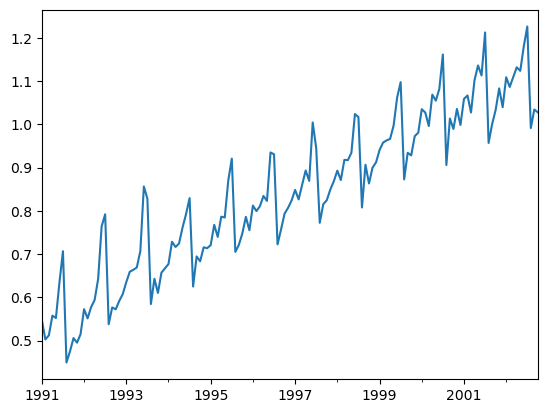

In [28]:
train_sales_log.plot()
plt.show();

### AR Model 

In [29]:
ar_aic = pd.DataFrame(columns=['param','AIC'])
ar_aic

,param,AIC


In [30]:
for param in pdq_ar:
    AR_model = ARIMA(train_sales_log, order=param).fit()
    ar_aic = pd.concat([ar_aic, pd.DataFrame({'param':[param],'AIC':[AR_model.aic]})],ignore_index=True)

In [31]:
ar_aic = ar_aic.sort_values(by='AIC')
ar_aic

,param,AIC
2,"(3, 0, 0)",-323.562214
1,"(2, 0, 0)",-319.001701
0,"(1, 0, 0)",-313.089506


In [32]:
best_results_ar = ARIMA(train_sales_log, order=(3,0,0)).fit()
print(best_results_ar.summary().tables[0])
print(best_results_ar.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  142
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 166.781
Date:                Wed, 30 Apr 2025   AIC                           -323.562
Time:                        20:28:15   BIC                           -308.783
Sample:                    01-31-1991   HQIC                          -317.557
                         - 10-31-2002                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8204      0.114      7.180      0.000       0.596       1.044
ar.L1          0.6491      0.130      5.006      0.000       0.395       0.903
ar.L2          0.0889      0.132      0.673      0.5

In [33]:
pred_dynamic_ar = best_results_ar.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred95_ar = best_results_ar.get_forecast(steps=len(test),alpha=0.05)
sales_ts_forecasted_ar = pred_dynamic_ar.predicted_mean
testcopy_ar = test.copy()
testcopy_ar['sales_ts_forecasted_ar'] = np.power(10, pred95_ar.predicted_mean)

In [34]:
mse_ar = ((testcopy_ar['Value'] - testcopy_ar['sales_ts_forecasted_ar'])**2).mean()
rmse_ar = np.sqrt(mse_ar)
rmse_ar

11.014835800476796

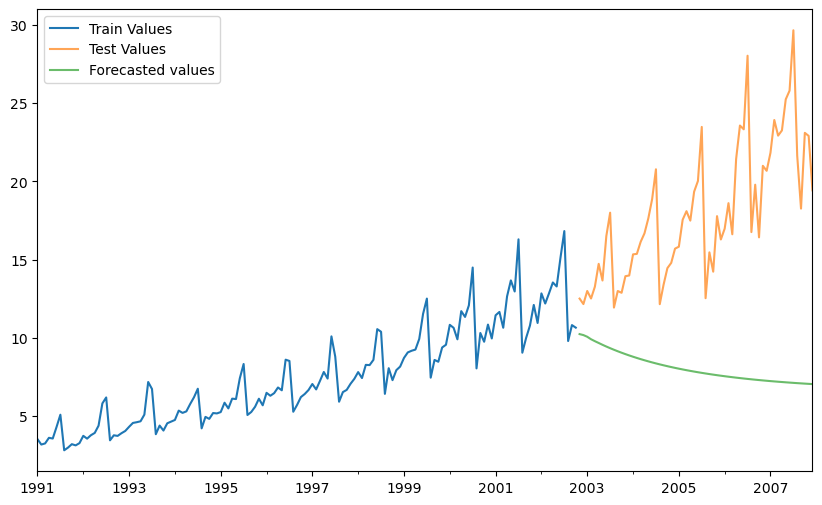

In [35]:
axis = train['Value'].plot(label='Train Values', figsize=(10,6))
test['Value'].plot(ax=axis, label='Test Values', alpha=0.7)
testcopy_ar['sales_ts_forecasted_ar'].plot(ax=axis, label='Forecasted values', alpha=0.7)
plt.legend()
plt.show()

In [36]:
resultsdf = pd.DataFrame({'Model':['AR(3,0,0)'],'RMSE':[rmse_ar]})
resultsdf

,Model,RMSE
0,"AR(3,0,0)",11.014836


### ARMA Model

In [37]:
arma_aic = pd.DataFrame(columns=['param','AIC'])
arma_aic

,param,AIC


In [38]:
for param in pdq_arma:
    ARMA_model = ARIMA(train_sales_log, order=param).fit()
    arma_aic = pd.concat([arma_aic, pd.DataFrame({'param':[param],'AIC':[ARMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [39]:
arma_aic = arma_aic.sort_values(by='AIC')
arma_aic

,param,AIC
8,"(3, 0, 3)",-344.742467
5,"(2, 0, 3)",-338.306667
1,"(1, 0, 2)",-336.434569
2,"(1, 0, 3)",-334.849105
4,"(2, 0, 2)",-334.740582
6,"(3, 0, 1)",-334.288691
7,"(3, 0, 2)",-332.378652
3,"(2, 0, 1)",-331.816277
0,"(1, 0, 1)",-326.873492


In [40]:
best_results_arma = ARIMA(train_sales_log, order=(3,0,3)).fit()
print(best_results_arma.summary().tables[0])
print(best_results_arma.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  142
Model:                 ARIMA(3, 0, 3)   Log Likelihood                 180.371
Date:                Wed, 30 Apr 2025   AIC                           -344.742
Time:                        20:28:18   BIC                           -321.096
Sample:                    01-31-1991   HQIC                          -335.133
                         - 10-31-2002                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0804    137.881     -0.001      1.000    -270.322     270.161
ar.L1         -0.4223      0.132     -3.194      0.001      -0.681      -0.163
ar.L2          0.9901      0.011     89.308      0.0

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [41]:
pred_dynamic_arma = best_results_arma.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred95_arma = best_results_arma.get_forecast(steps=len(test), alpha=0.05)
sales_ts_forecasted_arma = pred_dynamic_arma.predicted_mean
testcopy_arma = test.copy()
testcopy_arma['sales_ts_forecasted_arma'] = np.power(10, pred95_arma.predicted_mean)

In [42]:
mse_arma = ((testcopy_arma['Value'] - testcopy_arma['sales_ts_forecasted_arma'])**2).mean()
rmse_arma = np.sqrt(mse_arma)
rmse_arma

7.324418038475187

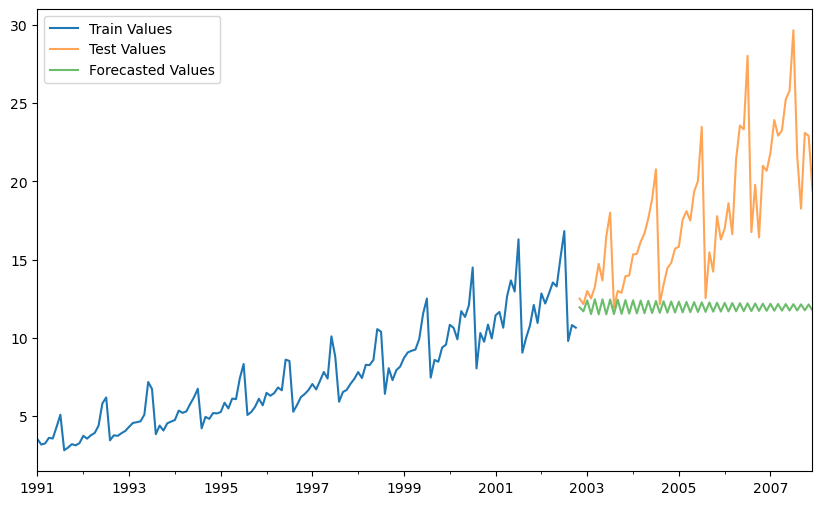

In [43]:
axis = train['Value'].plot(label='Train Values', figsize=(10,6))
testcopy_arma['Value'].plot(ax=axis, label='Test Values', alpha=0.7)
testcopy_arma['sales_ts_forecasted_arma'].plot(ax=axis, label='Forecasted Values', alpha=0.7)
plt.legend()
plt.show();

In [44]:
results_arma = pd.DataFrame({'Model':['ARMA(3,0,3)'],'RMSE':[rmse_arma]})
resultsdf = pd.concat([resultsdf, results_arma],ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(3,0,0)",11.014836
1,"ARMA(3,0,3)",7.324418


### ARIMA Model

In [45]:
arima_aic = pd.DataFrame(columns=['param','AIC'])
arima_aic

,param,AIC


In [46]:
for param in pdq_arima:
    ARIMA_model = ARIMA(train_sales_log, order=param).fit()
    arima_aic = pd.concat([arima_aic,pd.DataFrame({'param':[param],'AIC':[ARIMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [47]:
arima_aic = arima_aic.sort_values(by='AIC')
arima_aic

,param,AIC
17,"(3, 1, 3)",-364.041917
10,"(2, 1, 2)",-352.939830
5,"(1, 1, 3)",-345.541263
14,"(3, 0, 3)",-344.742467
3,"(1, 1, 1)",-340.289563
9,"(2, 1, 1)",-338.874264
4,"(1, 1, 2)",-338.788703
8,"(2, 0, 3)",-338.306667
15,"(3, 1, 1)",-337.088823
1,"(1, 0, 2)",-336.434569


In [48]:
best_results_arima = ARIMA(train_sales_log, order=(2,1,2)).fit()
print(best_results_arima.summary().tables[0])
print(best_results_arima.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  142
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 181.470
Date:                Wed, 30 Apr 2025   AIC                           -352.940
Time:                        20:28:22   BIC                           -338.196
Sample:                    01-31-1991   HQIC                          -346.948
                         - 10-31-2002                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3296      0.104     12.829      0.000       1.127       1.533
ar.L2         -0.3495      0.120     -2.924      0.003      -0.584      -0.115
ma.L1         -1.9775      0.241     -8.208      0.0

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [49]:
pred_dynamic_arima = best_results_arima.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred95_arima = best_results_arima.get_forecast(steps=len(test), alpha=0.05)
sales_ts_forecasted_arima = pred_dynamic_arima.predicted_mean
testcopy_arima = test.copy()
testcopy_arima['sales_ts_forecasted_arima']=np.power(10, pred95_arima.predicted_mean)

In [50]:
mse_arima = ((testcopy_arima['Value'] - testcopy_arima['sales_ts_forecasted_arima'])**2).mean()
rmse_arima = np.sqrt(mse_arima)
rmse_arima

6.610378271043983

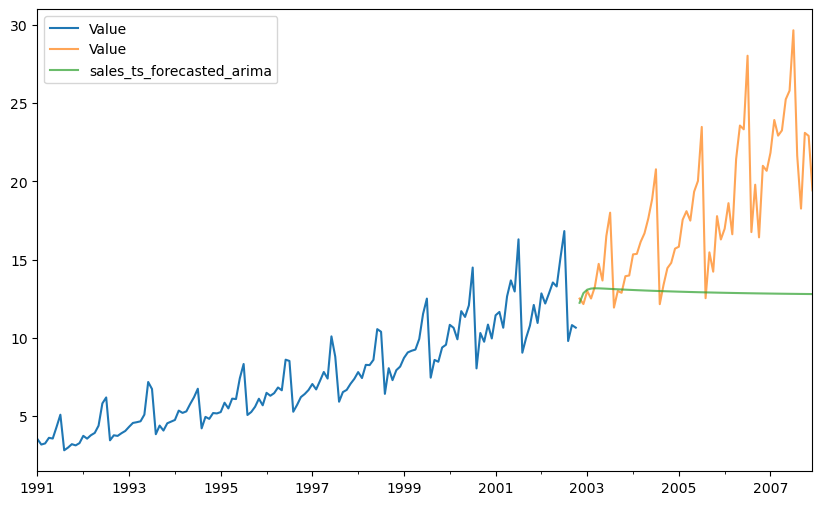

In [51]:
axis = train['Value'].plot(legend='Train Values', figsize =(10,6))
testcopy_arima['Value'].plot(ax=axis, legend='Test Values', alpha=0.7)
testcopy_arima['sales_ts_forecasted_arima'].plot(ax=axis, legend='Forecasted Values', alpha=0.7)
plt.legend()
plt.show();

In [52]:
results_arima = pd.DataFrame({'Model':['ARIMA(2,1,2)'], 'RMSE':[rmse_arima]})
resultsdf = pd.concat([resultsdf, results_arima],ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(3,0,0)",11.014836
1,"ARMA(3,0,3)",7.324418
2,"ARIMA(2,1,2)",6.610378


### SARIMA Model

In [53]:
sarima_aic = pd.DataFrame(columns=['param','seasonal','AIC'])
sarima_aic

,param,seasonal,AIC


In [54]:
for param in pdq_arima:
    for seasonal_param in pdq_sarima:
        SARIMA_model = sm.tsa.statespace.SARIMAX(train_sales_log,
                                                 order=param,
                                                 seasonal_order=seasonal_param,
                                                 enforce_stationarity=False,
                                                 enforce_invertibility=False).fit(maxiter=1000)
        sarima_aic = pd.concat([sarima_aic, pd.DataFrame({'param':[param],'seasonal':[seasonal_param],'AIC':[SARIMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [55]:
sarima_aic = sarima_aic.sort_values(by='AIC')
sarima_aic

,param,seasonal,AIC
7,"(1, 0, 1)","(2, 0, 2, 6)",-578.789705
115,"(2, 0, 1)","(2, 0, 2, 6)",-578.466277
259,"(3, 0, 3)","(2, 0, 2, 6)",-576.989195
61,"(1, 1, 1)","(2, 0, 2, 6)",-575.181731
313,"(3, 1, 3)","(2, 0, 2, 6)",-573.238312
...,...,...,...
288,"(3, 1, 2)","(1, 0, 1, 6)",-370.886420
252,"(3, 0, 3)","(1, 0, 1, 6)",-369.917085
144,"(2, 0, 3)","(1, 0, 1, 6)",-369.494844
0,"(1, 0, 1)","(1, 0, 1, 6)",-363.738704


In [56]:
best_results_sarima = sm.tsa.statespace.SARIMAX(train_sales_log,
                                                order = (2,0,1),
                                                seasonal_order = (1,0,1,6),
                                                enforce_stationarity=True).fit()
print(best_results_sarima.summary().tables[0])
print(best_results_sarima.summary().tables[1])

                                     SARIMAX Results                                     
Dep. Variable:                             Value   No. Observations:                  142
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 6)   Log Likelihood                 181.199
Date:                           Wed, 30 Apr 2025   AIC                           -350.398
Time:                                   20:36:09   BIC                           -332.663
Sample:                               01-31-1991   HQIC                          -343.191
                                    - 10-31-2002                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0205      0.157      0.131      0.896      -0.287       0.328
ar.L2          0.9792      0.157      6.238

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [57]:
pred_dynamic_sarima = best_results_sarima.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred95_sarima = best_results_sarima.get_forecast(steps=len(test),alpha=0.7)
sales_ts_forecasted_sarima = pred_dynamic_sarima.predicted_mean
testcopy_sarima = test.copy()
testcopy_sarima['sales_ts_forecasted_sarima'] = np.power(10, pred95_sarima.predicted_mean)

In [58]:
mse_sarima = ((testcopy_sarima['Value'] - testcopy_sarima['sales_ts_forecasted_sarima'])**2).mean()
rmse_sarima = np.sqrt(mse_sarima)
rmse_sarima

6.012080797781109

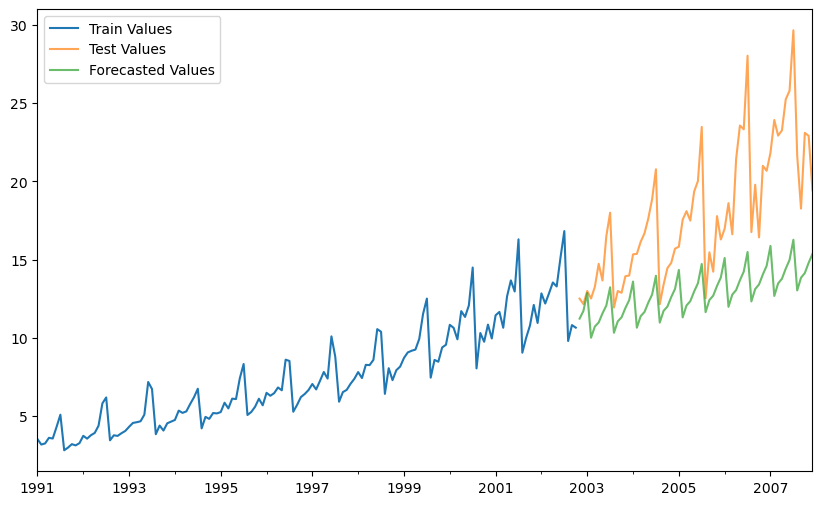

In [59]:
axis = train['Value'].plot(label = 'Train Values', figsize=(10,6))
testcopy_sarima['Value'].plot(ax=axis, label = 'Test Values', alpha=0.7)
testcopy_sarima['sales_ts_forecasted_sarima'].plot(ax=axis, label='Forecasted Values', alpha=0.7)
plt.legend()
plt.show()

In [60]:
results_sarima = pd.DataFrame({'Model':['SARIMA(2,0,1)(1,0,1,6)'],'RMSE':[rmse_sarima]})
resultsdf = pd.concat([resultsdf, results_sarima], ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(3,0,0)",11.014836
1,"ARMA(3,0,3)",7.324418
2,"ARIMA(2,1,2)",6.610378
3,"SARIMA(2,0,1)(1,0,1,6)",6.012081


## Best Model Fit - SARIMA

In [61]:
n_steps = 36
pred_uc_99 = best_results_sarima.get_forecast(steps = 36, alpha = 0.01)
pred_uc_95 = best_results_sarima.get_forecast(steps = 36, alpha = 0.05)
pred_ci_99 = pred_uc_99.conf_int()
pred_ci_95 = pred_uc_95.conf_int()

In [62]:
n_steps = 36
idx = pd.date_range(start='1/1/2008', periods=36, freq='MS')
fc_95 = pd.DataFrame(np.column_stack([np.power(10, pred_uc_95.predicted_mean), np.power(10, pred_ci_95)]),
                     index=idx, columns = ['forecast', 'lower_ci_95','upper_ci_95'])
fc_99 = pd.DataFrame(np.column_stack([np.power(10, pred_ci_99)]),index=idx, columns=['lower_ci_99','upper_ci_99'])
fc = fc_95.combine_first(fc_99)
fc = fc[['forecast', 'lower_ci_95','upper_ci_95','lower_ci_99','upper_ci_99']]
fc.head()

,forecast,lower_ci_95,upper_ci_95,lower_ci_99,upper_ci_99
2008-01-01,11.231237,8.431068,14.961412,8.431068,14.961412
2008-02-01,11.719704,7.825897,17.550891,7.825897,17.550891
2008-03-01,12.872240,7.844898,21.121314,7.844898,21.121314
2008-04-01,10.008710,5.654573,17.715621,5.654573,17.715621
2008-05-01,10.727227,5.663098,20.319866,5.663098,20.319866
